# Classification with PyTorch


## Parte 1: Clasificación de Iris
El conjunto de datos Iris contiene 150 registros de 3 clases diferentes de iris. Cada registro contiene 4 parámetros numéricos: largo/ancho del sépalo y largo/ancho del pétalo. Es un ejemplo de un conjunto de datos simple, para el cual no necesitas una red neuronal poderosa.

Obtener el conjunto de datos
El conjunto de datos Iris está incorporado en Scikit Learn, así que podemos obtenerlo fácilmente:

### Dataset

El conjunto de datos Iris está incorporado en Scikit Learn, así que podemos obtenerlo fácilmente:

In [39]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


### Visualizar los Datos

En muchos casos, tiene sentido visualizar los datos para ver si parecen separables; esto nos aseguraría que deberíamos poder construir un buen modelo de clasificación. Como tenemos pocas características, podemos construir una serie de gráficos de dispersión 2D por pares, mostrando diferentes clases con diferentes colores de puntos. Esto se puede hacer automáticamente con un paquete llamado **seaborn**:

In [46]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


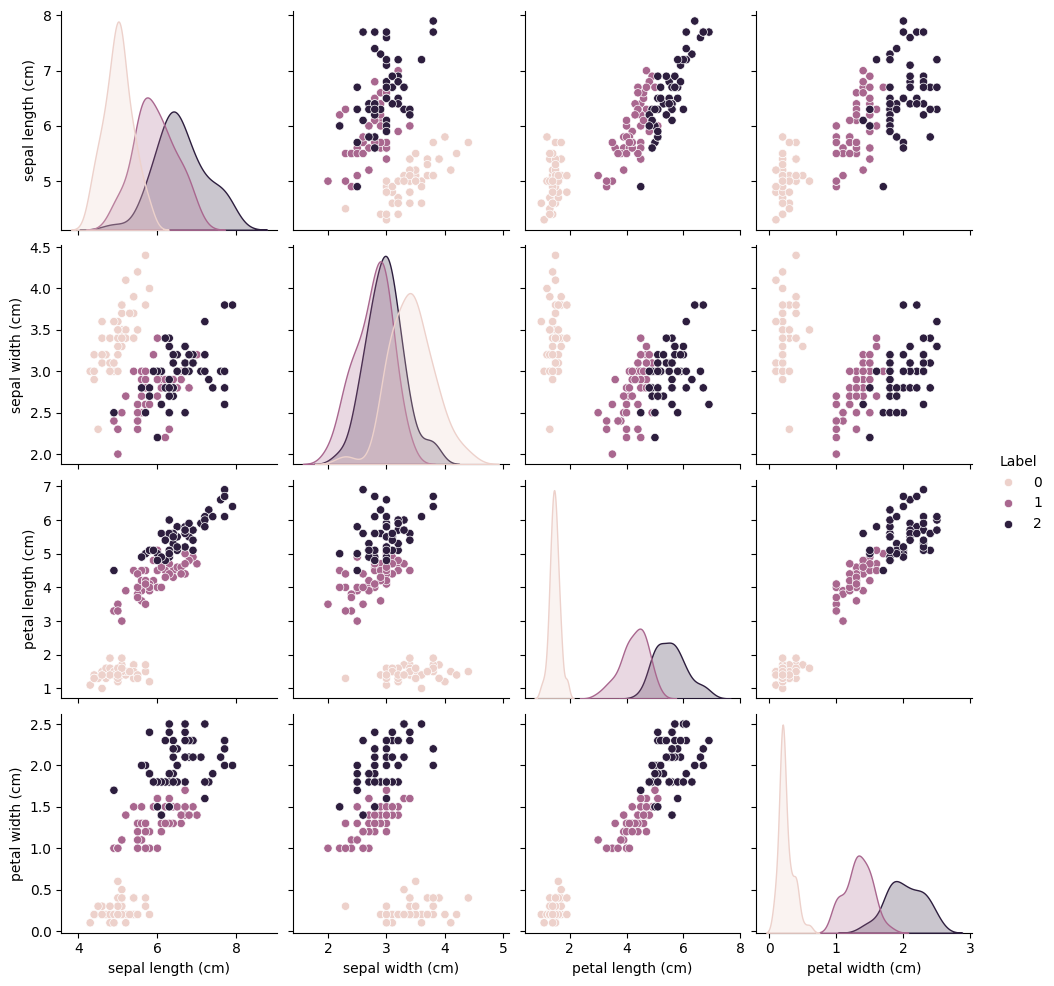

In [47]:
sns.pairplot(df,hue='Label')

### Normalizar y Codificar 

Para preparar los datos para el entrenamiento de la red neuronal, necesitamos normalizar las entradas en el rango [0..1]. Esto se puede hacer usando operaciones de numpy o métodos de Scikit Learn.


In [53]:
# Code to normalize and encode the data
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[feature_names], df['Label'], test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
y_train = y_train.values
y_test = y_test.values  

In [74]:
y_train_torch = torch.from_numpy(y_train)

### Train/Test Data Split

Como no tenemos un conjunto de datos de entrenamiento y prueba por separado, necesitamos dividirlo en conjuntos de entrenamiento y prueba usando Sklearn

[using Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [106]:
import torch 
from torch.utils.data import DataLoader, TensorDataset

X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
y_train=y_train.astype('int32')
y_test=y_test.astype('int32')   

X_train_torch = torch.from_numpy(X_train)
X_test_torch = torch.from_numpy(X_test)
y_test_torch = torch.from_numpy(y_test).float()
# On some computers the explicit cast to .float() is
# necessary
y_train_torch = torch.from_numpy(y_train).float()

train_ds = TensorDataset(X_train_torch, y_train_torch)

batch_size = X_train.shape[0]//4
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [75]:
for xb,yb in train_dl:
    print(xb.shape)
    print(yb.shape)
    break

torch.Size([30, 4])
torch.Size([30])


In [95]:
yb

tensor([2., 0., 2., 2., 0., 1., 2., 2., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0.,
        0., 0., 2., 2., 1., 2., 0., 1., 1., 0., 1., 2.])

### Define y Entrena Red Neuronal

Define la red neuronal y comienza el entrenamiento, observando el comportamiento de la precisión de entrenamiento y validación.

```
import torch 
from torch import nn

net = nn.Sequential(nn.Linear(4, 32),
                    nn.ReLU(),
                    nn.Linear(32, 3));
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);
```

In [107]:
# Define the network
# 
import torch 
from torch import nn

net = nn.Sequential(nn.Linear(4, 32),
                    nn.ReLU(),
                    nn.Linear(32, 3));
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.001)

net.apply(init_weights);

In [108]:
import torch.nn as nn 

optimizer = torch.optim.SGD(net.parameters(), lr=1e-1, momentum=0.9)
loss = nn.CrossEntropyLoss()

for i in range(100):
    
    for xb,yb in train_dl:
        y_hat= net(xb)
        output = loss(y_hat,yb.long())
        if i % 10 == 0:
            print(f"Epoch {i+1}")
            print("Loss value:", output.item())
        output.backward()
        optimizer.step()
        optimizer.zero_grad()

Epoch 1
Loss value: 1.1022758483886719
Epoch 1
Loss value: 1.1082442998886108
Epoch 1
Loss value: 1.0996308326721191
Epoch 1
Loss value: 1.0981696844100952
Epoch 11
Loss value: 1.0674662590026855
Epoch 11
Loss value: 1.076959490776062
Epoch 11
Loss value: 1.067168116569519
Epoch 11
Loss value: 1.0664055347442627
Epoch 21
Loss value: 0.30259525775909424
Epoch 21
Loss value: 0.27180585265159607
Epoch 21
Loss value: 0.28155767917633057
Epoch 21
Loss value: 0.28745242953300476
Epoch 31
Loss value: 0.10984806716442108
Epoch 31
Loss value: 0.09925355762243271
Epoch 31
Loss value: 0.1317845731973648
Epoch 31
Loss value: 0.12434308975934982
Epoch 41
Loss value: 0.08719947189092636
Epoch 41
Loss value: 0.09868398308753967
Epoch 41
Loss value: 0.05202239751815796
Epoch 41
Loss value: 0.07446470111608505
Epoch 51
Loss value: 0.15240737795829773
Epoch 51
Loss value: 0.04528302699327469
Epoch 51
Loss value: 0.05995019152760506
Epoch 51
Loss value: 0.08695943653583527
Epoch 61
Loss value: 0.04621141

In [93]:
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5).softmax(dim=1)
output = loss(input, target)
output.backward()

In [94]:
target

tensor([[0.1500, 0.1969, 0.2816, 0.2077, 0.1638],
        [0.0237, 0.3421, 0.0596, 0.0618, 0.5128],
        [0.0875, 0.4089, 0.1259, 0.0816, 0.2961]])

La funcion de perdida puede tomar valores reales (logits) 

```
loss = nn.CrossEntropyLoss()
input = torch.randn(3, 5, requires_grad=True)
target = torch.empty(3, dtype=torch.long).random_(5)
output = loss(input, target)
output.backward()

# Example of target with class probabilities
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5).softmax(dim=1)
output = loss(input, target)
output.backward()
```

In [5]:
# Train the network

In [6]:
# Visualize train/validation accuracy graph

### Experimento

Ahora puedes experimentar con diferentes arquitecturas de red para ver cómo afecta el resultado. Prueba:

1. Red de una sola capa con 3 neuronas (igual al número de clases)
2. Red de dos capas con una capa oculta pequeña/mediana/grande
3. Usar más capas

Asegúrate de observar sobreajuste cuando uses un modelo complejo con muchas neuronas (parámetros).

In [7]:
# Experiment

## Tarea : Detección de Fraudes

El conjunto de datos "Detección de Fraude con Tarjetas de Crédito" es un conjunto de datos públicos ampliamente utilizado para crear y evaluar modelos de aprendizaje automático, para detectar transacciones fraudulentas. Este conjunto de datos está alojado en Kaggle y se caracteriza por su alto desequilibrio de clases, donde las transacciones fraudulentas representan un porcentaje muy pequeño del total de transacciones.

```
import pandas as pd

raw_df = pd.read_csv('https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv')
```

**Características anonimizadas**:
La mayoría de las características (V1-V28) son numéricas y se han sometido a una transformación de Análisis de Componentes Principales (PCA) por motivos de privacidad.
Características de tiempo e importe:
La característica "Tiempo" representa los segundos transcurridos entre cada transacción y la primera transacción del conjunto de datos, mientras que "Importe" es el importe de la transacción. Estas dos características no se han transformado mediante PCA.

**Desequilibrio de clases:**
El conjunto de datos presenta un alto desequilibrio, con un número significativamente menor de transacciones fraudulentas (Clase 1) en comparación con las transacciones no fraudulentas (Clase 0). Este desequilibrio requiere una cuidadosa consideración durante el entrenamiento y la evaluación del modelo, lo que a menudo requiere técnicas como la ponderación de clase, el sobremuestreo o el submuestreo.
Clasificación binaria:
La característica "Clase" es la variable objetivo, que indica si una transacción es fraudulenta (1) o no fraudulenta (0), lo que la convierte en un problema de clasificación binaria.


**Carga y preprocesamiento de datos:**
Cargar el conjunto de datos (normalmente desde un archivo CSV), gestionar los valores faltantes, si los hubiera, y escalar o transformar características como "Tiempo" e "Importe", si es necesario.



**Construcción del modelo:**
Diseñar una arquitectura de red neuronal utilizando PyTorch, incluyendo capas como Dense, BatchNormalization y Dropout. 




**Entrenamiento:**
Compilar el modelo con una función de pérdida adecuada (p. ej., binary_crossentropy para clasificación binaria) y un optimizador, y entrenarlo con los datos preprocesados.

**Gestión del desequilibrio:**
Implementar estrategias para abordar el desequilibrio de clases, como el uso de class_weight durante el entrenamiento del modelo o la aplicación de técnicas de remuestreo de datos.

**Evaluación:**
Evaluar el rendimiento del modelo mediante métricas relevantes para conjuntos de datos desequilibrados, como la precisión, la recuperación, la puntuación F1 y el AUC-ROC.

In [8]:
# Load the dataset

import pandas as pd

raw_df = pd.read_csv('https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv')